已知向量 a = [2, −1, 3]⊤，b = [1, 4, −2]⊤，矩阵
A = [[1, 0, 2], [0, 3, 1]]，B = [[2, 1], [0,-1],[1, 3]]
计算：
1. 向量点积 a · b；
2. 矩阵乘法 A × B（结果矩阵的形状？）；
3. 向量 a 的 Frobenius 范数。
​
答：

1、向量点积 a⋅b点积计算公式：
a⋅b=∑i=1n​ai​bi​计算过程：a⋅b=2×1+(−1)×4+3×(−2)=2−4−6=−8

2、矩阵乘法 A×B 及结果形状矩阵乘法规则：
Am×k​×Bk×n​=Cm×n​此处 A 为 2×3 矩阵，B 为 3×2 矩阵，结果为2×2 矩阵计算过程：A×B=[1×2+0×0+2×3−1×2+3×0+1×3​1×1+0×(−1)+2×2−1×1+3×(−1)+1×2​]=[[8,​5],[1,−2​]]

3、向量 a 的 Frobenius 范数向量的 Frobenius 
范数等价于 L2 范数，公式：∥a∥F​=​≈3.7417

使用 NumPy（或 MXNet / PyTorch/TensorFlow）完成以下任务：
1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布。
2. 创建一个形状为 4 × 2 的全 1 矩阵 Y 。
3. 计算矩阵乘法 Z = X × Y 。
4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
5. 计算 Z 的 Frobenius 范数。

In [1]:
import torch

# 1. 创建3×4的随机矩阵X，元素服从标准正态分布
X = torch.randn(3, 4)
print("1. 3×4标准正态分布随机矩阵X：")
print(X, "\n")

# 2. 创建4×2的全1矩阵Y
Y = torch.ones(4, 2)
print("2. 4×2全1矩阵Y：")
print(Y, "\n")

# 3. 计算矩阵乘法Z = X × Y
Z = torch.matmul(X, Y)
print("3. 矩阵乘法结果Z = X×Y：")
print(Z, "\n")

# 4. 输出Z的第一行第二列元素，以及Z的第二行所有元素
# 注意：Python索引从0开始，第一行→索引0，第二列→索引1；第二行→索引1
target_element = Z[0, 1]
second_row = Z[1, :]
print("4. Z的第一行第二列交叉处的元素：", target_element.item())
print("   Z的第二行所有元素：", second_row, "\n")

# 5. 计算Z的Frobenius范数
f_norm = torch.norm(Z, p='fro')
print("5. Z的Frobenius范数：", f_norm.item())


1. 3×4标准正态分布随机矩阵X：
tensor([[ 1.4433,  0.6039, -0.4048,  1.4496],
        [ 1.1101,  1.5591, -0.1239,  1.4281],
        [-0.5174,  0.3674,  1.5689,  0.1973]]) 

2. 4×2全1矩阵Y：
tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]) 

3. 矩阵乘法结果Z = X×Y：
tensor([[3.0920, 3.0920],
        [3.9734, 3.9734],
        [1.6163, 1.6163]]) 

4. Z的第一行第二列交叉处的元素： 3.0919570922851562
   Z的第二行所有元素： tensor([3.9734, 3.9734]) 

5. Z的Frobenius范数： 7.478031158447266


3.1 概率与统计 贝叶斯公式计算题
已知条件

    事件 A：被测者患病，先验概率 P(A)=0.1%=0.001
    事件 ¬A：被测者未患病，P(¬A)=1−0.001=0.999
    灵敏度（真阳性率）：P(B∣A)=99%=0.99（患病时检测阳性的概率）
    假阳性率：P(B∣¬A)=2%=0.02（未患病时检测阳性的概率）
    目标：求检测阳性时真正患病的概率 P(A∣B)

计算过程

    1、贝叶斯公式：
    P(A∣B)=P(B)P(B∣A)P(A)​
    2、全概率公式计算边缘概率 P(B)：
    P(B)=P(B∣A)P(A)+P(B∣¬A)P(¬A)
    3、代入数值计算：

    分子：0.99×0.001=0.00099
    分母：0.99×0.001+0.02×0.999=0.00099+0.01998=0.02097

    最终结果：
    P(A∣B)=0.020970.00099​≈4.72%


3.2 编程题
用 Python 模拟中心极限定理：
1. 生成 n = 10000 个服从均匀分布 U(0, 1) 的随机变量，重复 m = 1000
次，每次计算这 n 个变量的均值。
2. 绘制这 1000 个均值的直方图，并叠加理论正态分布的概率密度曲线。
3. 计算这些均值的实际方差。

Missing colon in file WindowsPath('D:/develop/Anaconda/anaconda3/envs/yangyang/lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 413 (' use Unicode for the minus symbol rather than hyphen.  See')


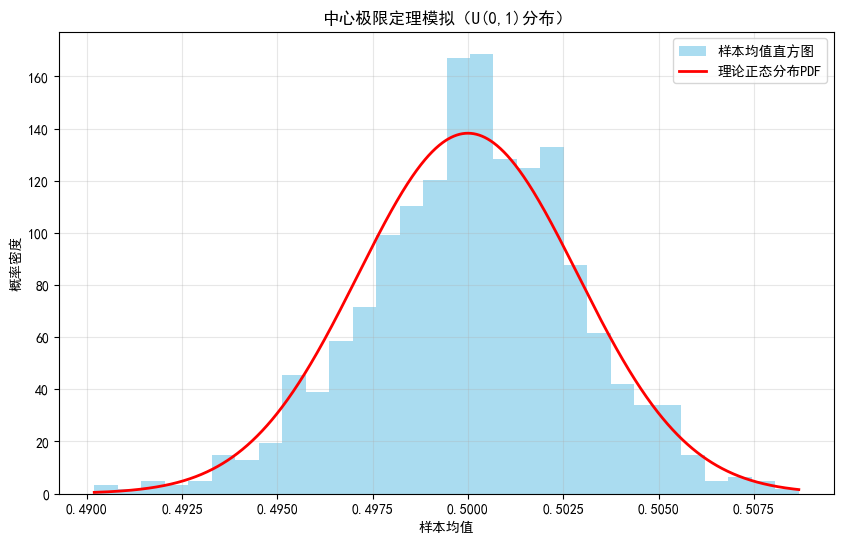

样本均值的实际方差：0.00000768
样本均值的理论方差：0.00000833


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 生成数据：n=10000个U(0,1)随机变量，重复m=1000次，计算每次的均值
n = 10000  # 单次实验的样本量
m = 1000   # 重复实验次数
# 生成m行n列的均匀分布随机数，每行计算均值
means = np.mean(np.random.uniform(0, 1, size=(m, n)), axis=1)

# 2. 绘制均值的直方图 + 理论正态分布曲线
plt.figure(figsize=(10, 6))
# 绘制直方图，density=True归一化为概率密度
plt.hist(means, bins=30, density=True, alpha=0.7, color='skyblue', label='样本均值直方图')

# 计算理论正态分布参数：U(0,1)的均值μ=0.5，方差σ²=1/12
mu_theory = 0.5
sigma_theory = np.sqrt(1/12 / n)  # 均值的方差=原方差/n
# 生成x轴数据
x = np.linspace(means.min(), means.max(), 1000)
# 计算理论正态分布概率密度
pdf_theory = norm.pdf(x, loc=mu_theory, scale=sigma_theory)
# 绘制理论曲线
plt.plot(x, pdf_theory, 'r-', linewidth=2, label='理论正态分布PDF')

# 图表美化
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理模拟（U(0,1)分布）')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. 计算均值的实际方差
var_actual = np.var(means, ddof=0)  # 总体方差
print(f"样本均值的实际方差：{var_actual:.8f}")
print(f"样本均值的理论方差：{sigma_theory**2:.8f}")


4.1 导数、反向传播 理论题
给定函数 z=(w1​x1​+w2​x2​−y)2，其中 x1​=2,x2​=1,y=3 为常数，w1​,w2​ 为变量。

    偏导数表达式推导令中间变量 u=w1​x1​+w2​x2​−y，则 z=u2，根据链式法则：∂w1​∂z​=∂u∂z​⋅∂w1​∂u​=2u⋅x1​代入 x1​=2,x2​=1,y=3，得：
    ∂w1​∂z​=4(2w1​+w2​−3)
    同理：∂w2​∂z​=∂u∂z​⋅∂w2​∂u​=2u⋅x2
    ​代入常数后得：
    ∂w2​∂z​=2(2w1​+w2​−3)
    
    2、w1​=0.5,w2​=1 时的梯度值
    先计算中间项：2w1​+w2​−3=2×0.5+1−3=−1
    代入偏导表达式：
    ∂w1​∂z​=4×(−1)=−4
    ∂w2​∂z​=2×(−1)=−2

4.2 编程题
手动实现一个简单计算图的反向传播：
1. 定义前向计算：输入 x，经过 a = x · w1，b = a + w2，输出 L = b
2。
2. 给定 x = 2, w1 = 1.5, w2 = 0.5，计算前向结果。
3. 手动（按链式法则）计算损失 L 对 w1, w2 的梯度，并验证与自动微分
工具（如 torch.autograd）的结果是否一致。

In [3]:
import torch
import numpy as np

# 1. 定义前向计算流程
# 前向公式：a = x·w1 , b = a + w2 , L = b²
def forward(x, w1, w2):
    a = x * w1
    b = a + w2
    L = b ** 2
    return a, b, L

# 2. 给定输入，计算前向结果
x = 2
w1 = 1.5
w2 = 0.5
a, b, L = forward(x, w1, w2)
print("前向计算结果：")
print(f"a = {a}, b = {b}, 损失L = {L}\n")

# 3. 手动链式法则计算梯度
# 链式法则：dL/dw1 = dL/db * db/da * da/dw1 ; dL/dw2 = dL/db * db/dw2
dL_db = 2 * b
db_da = 1
da_dw1 = x
db_dw2 = 1

# 最终梯度
dL_dw1_manual = dL_db * db_da * da_dw1
dL_dw2_manual = dL_db * db_dw2
print("手动计算的梯度：")
print(f"dL/dw1 = {dL_dw1_manual}")
print(f"dL/dw2 = {dL_dw2_manual}\n")

# 4. PyTorch自动微分验证
# 定义带梯度的张量
w1_torch = torch.tensor(1.5, requires_grad=True)
w2_torch = torch.tensor(0.5, requires_grad=True)
x_torch = torch.tensor(2.0)

# 前向计算
a_torch = x_torch * w1_torch
b_torch = a_torch + w2_torch
L_torch = b_torch ** 2

# 反向传播
L_torch.backward()

# 提取自动微分的梯度
dL_dw1_auto = w1_torch.grad.item()
dL_dw2_auto = w2_torch.grad.item()
print("PyTorch自动微分计算的梯度：")
print(f"dL/dw1 = {dL_dw1_auto}")
print(f"dL/dw2 = {dL_dw2_auto}\n")

# 验证一致性
print("梯度一致性验证：")
print(f"w1梯度是否一致：{np.isclose(dL_dw1_manual, dL_dw1_auto)}")
print(f"w2梯度是否一致：{np.isclose(dL_dw2_manual, dL_dw2_auto)}")


前向计算结果：
a = 3.0, b = 3.5, 损失L = 12.25

手动计算的梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

PyTorch自动微分计算的梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

梯度一致性验证：
w1梯度是否一致：True
w2梯度是否一致：True


5.1 线性方法、基础优化 理论题
线性回归模型 y=wx+b，均方误差损失：L=n1​∑i=1n​(yi​−(wxi​+b))2推导损失对 w 和 b 的偏导数（题目中 “u” 为 “w” 笔误）。
推导过程
令残差 ei​=yi​−(wxi​+b)，则损失可写为 L=n1​∑i=1n​ei2​

    对 w 求偏导：∂w∂L​=n1​∑i=1n​2ei​⋅∂w∂ei​​=n1​∑i=1n​2(yi​−wxi​−b)⋅(−xi​)化简得：∂w∂L​=−n2​∑i=1n​xi​(yi​−wxi​−b)
    对 b 求偏导：∂b∂L​=n1​∑i=1n​2ei​⋅∂b∂ei​​=n1​∑i=1n​2(yi​−wxi​−b)⋅(−1)化简得：∂b∂L​=−n2​∑i=1n​(yi​−wxi​−b)

5.2 编程题
从零实现 softmax 回归对手写数字（MNIST）进行分类：
1. 使用 sklearn.datasets.load_digits() 或自己加载 MNIST 子集。
2. 将图像展平为向量，对标签进行 one‑hot 编码。
3. 实现 softmax 函数、交叉熵损失函数。
4. 使用小批量随机梯度下降（批量大小 32，学习率 0.1）训练模型 50 个
epoch。
5. 输出测试集上的准确率。

In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. 加载数据集并预处理
digits = load_digits()
X = digits.data  # 形状：(1797, 64)，8×8图像展平为64维向量
y = digits.target.reshape(-1, 1)  # 标签形状：(1797, 1)

# 数据归一化：缩放到[0,1]
X = X / 16.0  # 像素值范围0~16

# 标签one-hot编码
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)  # 形状：(1797, 10)

# 划分训练集和测试集（7:3）
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.3, random_state=42)

# 2. 定义核心函数
def softmax(Z):
    """softmax函数，防止数值溢出做了中心化处理"""
    Z_max = np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z - Z_max)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    """交叉熵损失函数，添加极小值防止log(0)"""
    n_samples = y_pred.shape[0]
    epsilon = 1e-10
    loss = -np.sum(y_true * np.log(y_pred + epsilon)) / n_samples
    return loss

# 3. 初始化模型参数
n_features = X_train.shape[1]  # 64
n_classes = y_train.shape[1]   # 10
W = np.random.randn(n_features, n_classes) * 0.01  # 权重矩阵
b = np.zeros((1, n_classes))  # 偏置项

# 4. 小批量随机梯度下降训练
batch_size = 32
learning_rate = 0.1
epochs = 50
n_samples = X_train.shape[0]

print("开始训练softmax回归模型：")
for epoch in range(epochs):
    # 打乱训练集
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]
    
    # 小批量迭代
    for i in range(0, n_samples, batch_size):
        # 取当前批次数据
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        batch_n = X_batch.shape[0]
        
        # 前向传播
        Z = np.dot(X_batch, W) + b
        y_pred = softmax(Z)
        
        # 计算梯度
        dW = np.dot(X_batch.T, (y_pred - y_batch)) / batch_n
        db = np.sum(y_pred - y_batch, axis=0, keepdims=True) / batch_n
        
        # 参数更新
        W -= learning_rate * dW
        b -= learning_rate * db
    
    # 每10个epoch打印训练损失
    if (epoch + 1) % 10 == 0:
        Z_train = np.dot(X_train, W) + b
        y_pred_train = softmax(Z_train)
        train_loss = cross_entropy_loss(y_pred_train, y_train)
        print(f"Epoch [{epoch+1}/{epochs}], 训练损失：{train_loss:.4f}")

# 5. 测试集准确率计算
Z_test = np.dot(X_test, W) + b
y_pred_test = softmax(Z_test)
# 取概率最大的类别为预测结果
y_pred_label = np.argmax(y_pred_test, axis=1)
y_test_label = np.argmax(y_test, axis=1)
# 计算准确率
accuracy = np.sum(y_pred_label == y_test_label) / len(y_test_label)
print(f"\n测试集分类准确率：{accuracy:.4f} (约{accuracy*100:.2f}%)")


开始训练softmax回归模型：
Epoch [10/50], 训练损失：0.4718
Epoch [20/50], 训练损失：0.3142
Epoch [30/50], 训练损失：0.2513
Epoch [40/50], 训练损失：0.2165
Epoch [50/50], 训练损失：0.1934

测试集分类准确率：0.9593 (约95.93%)


6.1 最大似然估计 理论题
样本 x1​,x2​,...,xn​ 独立同分布于正态分布 N(μ,σ2)。

    1、似然函数 L(μ,σ2)
    单个样本的概率密度函数：f(xi​;μ,σ2)=2πσ2
    ​1​exp(−2σ2(xi​−μ)2​)
    独立样本的联合似然函数为各样本密度的乘积：
    L(μ,σ2)=(2πσ2)−2n​exp(−2σ21​∑i=1n​(xi​−μ)2)
    为方便求导，取对数似然函数：
    lnL(μ,σ2)=−2n​ln(2π)−2n​ln(σ2)−2σ21​∑i=1n​(xi​−μ)2
    
    2、证明 μ^​=n1​∑i=1n​xi​ 是μ的最大似然估计
    对μ求偏导并令其为 0：
    ∂μ∂lnL​=σ21​∑i=1n​(xi​−μ)=0
    化简得：∑i=1n​xi​−nμ=0⟹μ^​=n1​∑i=1n​xi
    ​二阶偏导恒小于 0，该点为极大值点，即最大似然估计，得证。
    
    3、证明 σ^2=n1​∑i=1n​(xi​−μ^​)2 是σ2的最大似然估计
    令θ=σ2，对θ求偏导并令其为 0：
    ∂θ∂lnL​=−2θn​+2θ21​∑i=1n​(xi​−μ)2=0
    两边同乘2θ2化简：−nθ+∑i=1n​(xi​−μ)2=0⟹θ^=n1​∑i=1n​(xi​−μ)2
    代入μ的最大似然估计μ^​，得：
    σ^2=n1​∑i=1n​(xi​−μ^​)2
    二阶偏导恒小于 0，该点为极大值点，即最大似然估计，得证。

6.2 编程题
实现二分类逻辑回归模型（不使用深度学习框架的高阶 API）：
1. 生成两类线性可分的数据：每类 200 个样本，特征维度为 2。
2. 定义 sigmoid 函数和二元交叉熵损失。
3. 使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 w, b。
4. 绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类
准确率。

开始训练逻辑回归模型：
Epoch [100/1000], 训练损失：0.4090
Epoch [200/1000], 训练损失：0.3058
Epoch [300/1000], 训练损失：0.2471
Epoch [400/1000], 训练损失：0.2098
Epoch [500/1000], 训练损失：0.1840
Epoch [600/1000], 训练损失：0.1652
Epoch [700/1000], 训练损失：0.1507
Epoch [800/1000], 训练损失：0.1392
Epoch [900/1000], 训练损失：0.1299
Epoch [1000/1000], 训练损失：0.1222

测试集分类准确率：0.9625 (约96.25%)


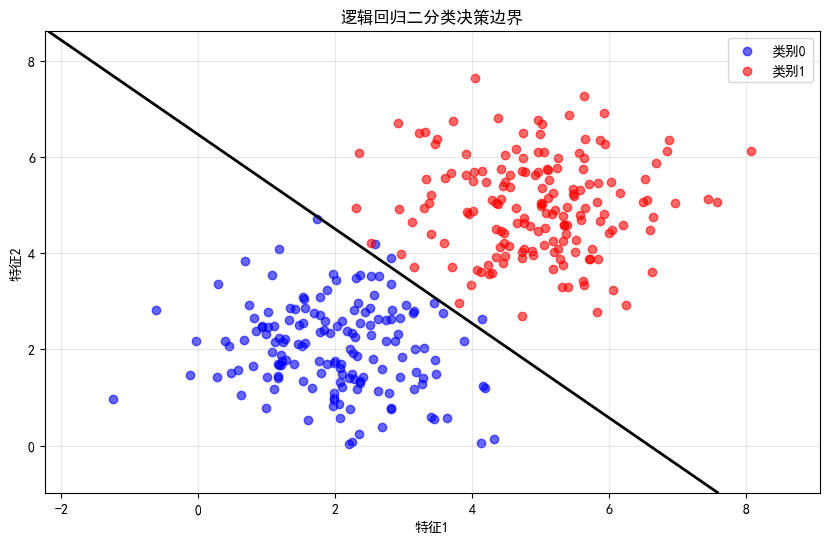

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. 生成两类线性可分数据
np.random.seed(42)  # 固定随机种子，结果可复现
n_samples_per_class = 200
n_features = 2

# 生成两类数据，均值不同保证线性可分
# 类别0：均值[2,2]，协方差单位矩阵
X0 = np.random.multivariate_normal(mean=[2, 2], cov=np.eye(n_features), size=n_samples_per_class)
y0 = np.zeros((n_samples_per_class, 1))
# 类别1：均值[5,5]，协方差单位矩阵
X1 = np.random.multivariate_normal(mean=[5, 5], cov=np.eye(n_features), size=n_samples_per_class)
y1 = np.ones((n_samples_per_class, 1))

# 合并数据
X = np.vstack((X0, X1))
y = np.vstack((y0, y1))

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 定义核心函数
def sigmoid(z):
    """sigmoid激活函数，限制数值范围防止溢出"""
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    """二元交叉熵损失函数"""
    n_samples = y_pred.shape[0]
    epsilon = 1e-10
    loss = -np.sum(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon)) / n_samples
    return loss

# 3. 初始化参数
W = np.random.randn(n_features, 1) * 0.01
b = np.zeros((1, 1))
learning_rate = 0.1
epochs = 1000
n_samples = X_train.shape[0]

# 4. 梯度下降训练
print("开始训练逻辑回归模型：")
for epoch in range(epochs):
    # 前向传播
    z = np.dot(X_train, W) + b
    y_pred = sigmoid(z)
    
    # 计算梯度
    dW = np.dot(X_train.T, (y_pred - y_train)) / n_samples
    db = np.sum(y_pred - y_train) / n_samples
    
    # 参数更新
    W -= learning_rate * dW
    b -= learning_rate * db
    
    # 每100轮打印损失
    if (epoch + 1) % 100 == 0:
        loss = binary_cross_entropy(y_pred, y_train)
        print(f"Epoch [{epoch+1}/{epochs}], 训练损失：{loss:.4f}")

# 5. 测试集准确率计算
z_test = np.dot(X_test, W) + b
y_pred_test = sigmoid(z_test)
# 概率≥0.5判为类别1，否则为类别0
y_pred_label = (y_pred_test >= 0.5).astype(int)
accuracy = np.sum(y_pred_label == y_test) / len(y_test)
print(f"\n测试集分类准确率：{accuracy:.4f} (约{accuracy*100:.2f}%)")

# 6. 绘制决策边界
plt.figure(figsize=(10, 6))
# 绘制训练数据点
plt.scatter(X_train[y_train[:,0]==0, 0], X_train[y_train[:,0]==0, 1], c='blue', label='类别0', alpha=0.6)
plt.scatter(X_train[y_train[:,0]==1, 0], X_train[y_train[:,0]==1, 1], c='red', label='类别1', alpha=0.6)

# 生成决策边界网格
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                        np.arange(x2_min, x2_max, 0.02))
# 计算网格点的预测概率
z_grid = np.dot(np.c_[xx1.ravel(), xx2.ravel()], W) + b
y_grid = sigmoid(z_grid)
y_grid = y_grid.reshape(xx1.shape)
# 绘制决策边界（概率=0.5的等高线）
plt.contour(xx1, xx2, y_grid, levels=[0.5], colors='black', linewidths=2)

# 图表美化
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('逻辑回归二分类决策边界')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
